In [4]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [5]:
import sys
sys.path.append("..") 

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [4]:
WINDOW_SIZE = 1000      # 8 seconds at 125 Hz
STEP_SIZE = 500         # 50% overlap


In [5]:
from UCI.pre_processing import extract_bp_from_abp, process_recording, process_split

In [6]:
recordings = []

for part in range(1, 5):

    file_path = f"../UCI/data/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]

    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )

print("Total recordings:", len(recordings))

Total recordings: 12000


In [7]:
train_records, test_records = train_test_split(
    recordings,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_records, val_records = train_test_split(
    train_records,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print(len(train_records))
print(len(val_records))
print(len(test_records))

8640
960
2400


In [8]:
X_train, y_train = process_split(train_records)

X_val, y_val = process_split(val_records)

X_test, y_test = process_split(test_records)

X_train = X_train[:,None,:]
X_val = X_val[:,None,:]
X_test = X_test[:,None,:]

100%|██████████| 8640/8640 [01:35<00:00, 90.25it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:10<00:00, 88.55it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:27<00:00, 87.51it/s] 


Skipped recordings: 1


In [9]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [10]:
print("SBP range:")
print(y_train[:,0].min(), y_train[:,0].max())

print("\nDBP range:")
print(y_train[:,1].min(), y_train[:,1].max())

SBP range:
tensor(62.5815) tensor(199.2841)

DBP range:
tensor(50.) tensor(149.9514)


In [11]:
class PPGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [12]:
train_dataset = PPGDataset(
    X_train,
    y_train
)

val_dataset = PPGDataset(
    X_val,
    y_val
)

test_dataset = PPGDataset(
    X_test,
    y_test
)

In [13]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [14]:
x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([64, 1, 1000])
torch.Size([64, 2])


In [15]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM

model = CNN_LSTM().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [26]:
EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/50 | Train MSE: 2033.87 (SBP RMSE: 40.44, DBP RMSE: 19.97) | Val MSE: 503.46 (SBP RMSE: 19.70, DBP RMSE: 10.74)
Epoch 2/50 | Train MSE: 670.42 (SBP RMSE: 22.69, DBP RMSE: 12.48) | Val MSE: 476.34 (SBP RMSE: 19.29, DBP RMSE: 10.20)
Epoch 3/50 | Train MSE: 621.55 (SBP RMSE: 21.78, DBP RMSE: 12.14) | Val MSE: 452.54 (SBP RMSE: 18.76, DBP RMSE: 10.04)
Epoch 4/50 | Train MSE: 591.60 (SBP RMSE: 21.18, DBP RMSE: 11.95) | Val MSE: 456.25 (SBP RMSE: 18.82, DBP RMSE: 10.10)
Epoch 5/50 | Train MSE: 551.62 (SBP RMSE: 20.36, DBP RMSE: 11.71) | Val MSE: 452.77 (SBP RMSE: 18.64, DBP RMSE: 10.26)
Epoch 6/50 | Train MSE: 521.36 (SBP RMSE: 19.71, DBP RMSE: 11.53) | Val MSE: 444.92 (SBP RMSE: 18.63, DBP RMSE: 9.89)
Epoch 7/50 | Train MSE: 499.82 (SBP RMSE: 19.23, DBP RMSE: 11.40) | Val MSE: 453.86 (SBP RMSE: 18.83, DBP RMSE: 9.96)
Epoch 8/50 | Train MSE: 475.81 (SBP RMSE: 18.73, DBP RMSE: 11.18) | Val MSE: 446.41 (SBP RMSE: 18.57, DBP RMSE: 10.09)
Epoch 9/50 | Train MSE: 435.37 (SBP RMSE: 17.89, 

## OBSERVATION ##

- Validation error is very very high than training -> The model is clearly overfitting (starts around 8-9 epoch)

- We'll try regularization and if it doesn't work we'll reduce CNN layers

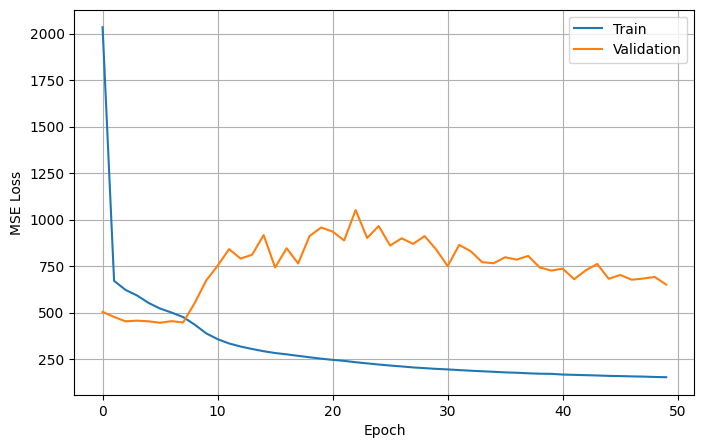

In [27]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [28]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [29]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 18.38 mmHg
DBP MAE: 9.81 mmHg


In [30]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 22.53 mmHg
DBP RMSE: 12.83 mmHg


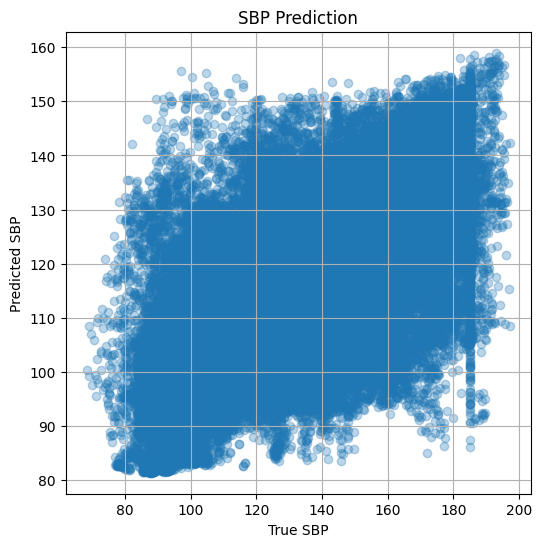

In [31]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,0],
    predictions[:,0],
    alpha=0.3
)

plt.xlabel("True SBP")
plt.ylabel("Predicted SBP")
plt.title("SBP Prediction")

plt.grid()
plt.show()

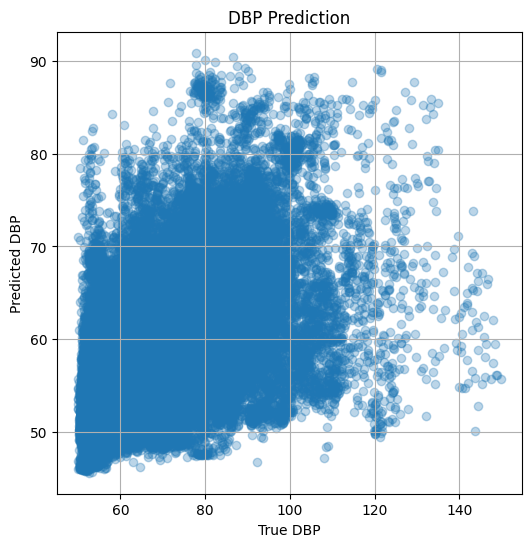

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets[:,1],
    predictions[:,1],
    alpha=0.3
)

plt.xlabel("True DBP")
plt.ylabel("Predicted DBP")
plt.title("DBP Prediction")

plt.grid()
plt.show()

Added dropout and weight decay to the model

In [ ]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM

model = CNN_LSTM().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [34]:
EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/50 | Train MSE: 2125.83 (SBP RMSE: 41.45, DBP RMSE: 20.19) | Val MSE: 529.33 (SBP RMSE: 20.33, DBP RMSE: 10.78)
Epoch 2/50 | Train MSE: 686.60 (SBP RMSE: 22.98, DBP RMSE: 12.58) | Val MSE: 485.77 (SBP RMSE: 19.59, DBP RMSE: 10.10)
Epoch 3/50 | Train MSE: 633.24 (SBP RMSE: 22.00, DBP RMSE: 12.23) | Val MSE: 473.60 (SBP RMSE: 19.29, DBP RMSE: 10.07)
Epoch 4/50 | Train MSE: 583.79 (SBP RMSE: 21.04, DBP RMSE: 11.88) | Val MSE: 511.21 (SBP RMSE: 20.08, DBP RMSE: 10.39)
Epoch 5/50 | Train MSE: 543.40 (SBP RMSE: 20.23, DBP RMSE: 11.59) | Val MSE: 489.68 (SBP RMSE: 19.46, DBP RMSE: 10.54)
Epoch 6/50 | Train MSE: 503.12 (SBP RMSE: 19.39, DBP RMSE: 11.28) | Val MSE: 533.10 (SBP RMSE: 20.32, DBP RMSE: 10.96)
Epoch 7/50 | Train MSE: 455.29 (SBP RMSE: 18.35, DBP RMSE: 10.88) | Val MSE: 695.09 (SBP RMSE: 23.13, DBP RMSE: 12.65)
Epoch 8/50 | Train MSE: 417.60 (SBP RMSE: 17.50, DBP RMSE: 10.56) | Val MSE: 856.81 (SBP RMSE: 25.66, DBP RMSE: 14.09)
Epoch 9/50 | Train MSE: 387.51 (SBP RMSE: 16.75

KeyboardInterrupt: 

**Still overfitting**

-Trying to normalise target and then check

In [16]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM

model = CNN_LSTM().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [17]:
import numpy as np


# Mean and standard deviation of BP targets

y_mean = y_train.mean(axis=0)

y_std = y_train.std(axis=0)


print("SBP mean:", y_mean[0])
print("SBP std :", y_std[0])

print("DBP mean:", y_mean[1])
print("DBP std :", y_std[1])

SBP mean: tensor(129.5934)
SBP std : tensor(22.2738)
DBP mean: tensor(66.7786)
DBP std : tensor(11.2347)


In [18]:
y_train_norm = (
    y_train - y_mean
) / y_std


y_val_norm = (
    y_val - y_mean
) / y_std


y_test_norm = (
    y_test - y_mean
) / y_std

In [19]:
y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)

/tmp/ipykernel_377611/2247437078.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
/tmp/ipykernel_377611/2247437078.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
/tmp/ipykernel_377611/2247437078.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)


In [20]:
train_dataset = PPGDataset(
    X_train,
    y_train_norm
)

val_dataset = PPGDataset(
    X_val,
    y_val_norm
)

test_dataset = PPGDataset(
    X_test,
    y_test_norm
)

In [21]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [22]:
EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})")

Epoch 1/50 | Train MSE: 1.76 (SBP RMSE: 0.92, DBP RMSE: 0.95) | Val MSE: 1.61 (SBP RMSE: 0.90, DBP RMSE: 0.89)
Epoch 2/50 | Train MSE: 1.63 (SBP RMSE: 0.89, DBP RMSE: 0.91) | Val MSE: 1.62 (SBP RMSE: 0.91, DBP RMSE: 0.88)
Epoch 3/50 | Train MSE: 1.58 (SBP RMSE: 0.88, DBP RMSE: 0.90) | Val MSE: 1.56 (SBP RMSE: 0.89, DBP RMSE: 0.88)
Epoch 4/50 | Train MSE: 1.54 (SBP RMSE: 0.86, DBP RMSE: 0.89) | Val MSE: 1.50 (SBP RMSE: 0.87, DBP RMSE: 0.86)
Epoch 5/50 | Train MSE: 1.51 (SBP RMSE: 0.86, DBP RMSE: 0.88) | Val MSE: 1.46 (SBP RMSE: 0.87, DBP RMSE: 0.84)
Epoch 6/50 | Train MSE: 1.49 (SBP RMSE: 0.85, DBP RMSE: 0.88) | Val MSE: 1.50 (SBP RMSE: 0.88, DBP RMSE: 0.85)
Epoch 7/50 | Train MSE: 1.47 (SBP RMSE: 0.84, DBP RMSE: 0.87) | Val MSE: 1.50 (SBP RMSE: 0.88, DBP RMSE: 0.85)
Epoch 8/50 | Train MSE: 1.45 (SBP RMSE: 0.84, DBP RMSE: 0.87) | Val MSE: 1.43 (SBP RMSE: 0.85, DBP RMSE: 0.84)
Epoch 9/50 | Train MSE: 1.44 (SBP RMSE: 0.83, DBP RMSE: 0.86) | Val MSE: 1.44 (SBP RMSE: 0.86, DBP RMSE: 0.84)
E

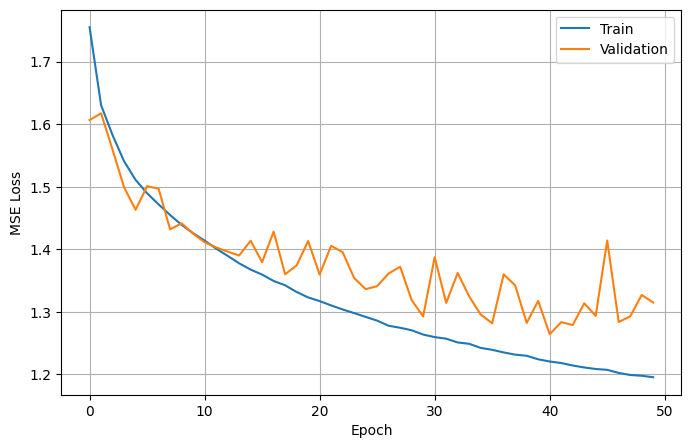

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [26]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.cpu().numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


# ------------------------------------
# Denormalize back to mmHg
# ------------------------------------
y_mean = y_mean.cpu().numpy()
y_std = y_std.cpu().numpy()
predictions = predictions * y_std + y_mean
targets = targets * y_std + y_mean


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

print("\nFirst 5 Predictions (mmHg):")
print(predictions[:5])

print("\nFirst 5 Targets (mmHg):")
print(targets[:5])

Predictions shape: (133841, 2)
Targets shape: (133841, 2)

First 5 Predictions (mmHg):
[[126.35506   61.446415]
 [124.869316  60.6712  ]
 [128.15723   62.177715]
 [123.9414    63.65213 ]
 [130.3263    65.03856 ]]

First 5 Targets (mmHg):
[[143.30846   60.371254]
 [142.83955   58.99385 ]
 [143.4843    60.40056 ]
 [149.11113   61.57282 ]
 [152.39346   61.54351 ]]


In [ ]:
sbp_mae = mean_absolute_error(
    targets[:, 0],
    predictions[:, 0]
)
dbp_mae = mean_absolute_error(
    targets[:, 1],
    predictions[:, 1]
)

In [29]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:, 0],
        predictions[:, 0]
    )
)
dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:, 1],
        predictions[:, 1]
    )
)
print(f"SBP MAE  : {sbp_mae:.2f} mmHg")
print(f"SBP RMSE : {sbp_rmse:.2f} mmHg")
print(f"DBP MAE  : {dbp_mae:.2f} mmHg")
print(f"DBP RMSE : {dbp_rmse:.2f} mmHg")

SBP MAE  : 13.55 mmHg
SBP RMSE : 17.93 mmHg
DBP MAE  : 6.54 mmHg
DBP RMSE : 9.43 mmHg


## Reducing the size of the CNN ## 
(as the model is still overfitting)

- The targets are not normalized 


In [7]:
class CNN_LSTM_small(nn.Module):

    def __init__(self):

        super().__init__()


        # CNN Feature Extractor (smaller)

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU()

        )


        # LSTM

        self.lstm = nn.LSTM(

            input_size=64,   # changed from 128

            hidden_size=64,

            num_layers=2,

            batch_first=True,

            dropout=0.3

        )


        # Regression Head

        self.regressor = nn.Sequential(

            nn.Linear(64,64),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64,32),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32,2)

        )


    def forward(self,x):

        # CNN
        x = self.features(x)

        # (batch, channels, sequence)
        # Convert for LSTM

        x = x.permute(0,2,1)

        # (batch, sequence, features)

        output, (hidden, cell) = self.lstm(x)


        # Last hidden state

        x = hidden[-1]


        x = self.regressor(x)

        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM_small().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [9]:
from UCI.pre_processing import extract_bp_from_abp, process_recording, process_split, load_UCI_dataset, create_dataloaders
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset()

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:38<00:00, 87.60it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:11<00:00, 85.96it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:28<00:00, 85.71it/s] 


Skipped recordings: 1


In [10]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_535769/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_535769/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_535769/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_535769/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone()

In [12]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [13]:
EPOCHS = 50

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/50 | Train MSE: 2502.19 (SBP RMSE: 44.65, DBP RMSE: 22.55) | Val MSE: 652.66 (SBP RMSE: 22.77, DBP RMSE: 11.59)
Epoch 2/50 | Train MSE: 1226.32 (SBP RMSE: 30.98, DBP RMSE: 16.32) | Val MSE: 515.27 (SBP RMSE: 20.11, DBP RMSE: 10.54)
Epoch 3/50 | Train MSE: 1161.98 (SBP RMSE: 30.13, DBP RMSE: 15.94) | Val MSE: 560.86 (SBP RMSE: 21.05, DBP RMSE: 10.84)
Epoch 4/50 | Train MSE: 1091.25 (SBP RMSE: 29.18, DBP RMSE: 15.49) | Val MSE: 517.24 (SBP RMSE: 20.20, DBP RMSE: 10.44)
Epoch 5/50 | Train MSE: 1018.17 (SBP RMSE: 28.16, DBP RMSE: 15.00) | Val MSE: 481.28 (SBP RMSE: 19.55, DBP RMSE: 9.95)
Epoch 6/50 | Train MSE: 978.13 (SBP RMSE: 27.58, DBP RMSE: 14.74) | Val MSE: 470.74 (SBP RMSE: 19.12, DBP RMSE: 10.26)
Epoch 7/50 | Train MSE: 958.29 (SBP RMSE: 27.31, DBP RMSE: 14.57) | Val MSE: 474.55 (SBP RMSE: 19.37, DBP RMSE: 9.98)
Epoch 8/50 | Train MSE: 921.42 (SBP RMSE: 26.75, DBP RMSE: 14.35) | Val MSE: 459.51 (SBP RMSE: 18.92, DBP RMSE: 10.07)
Epoch 9/50 | Train MSE: 887.63 (SBP RMSE: 26.

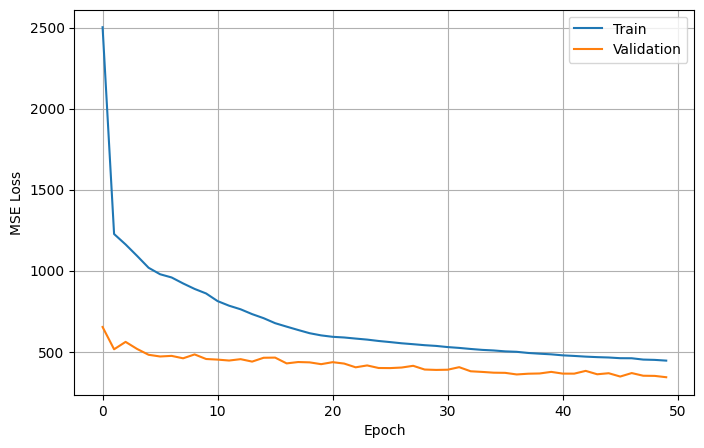

In [14]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [15]:
model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [17]:

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 11.76 mmHg
DBP MAE: 6.41 mmHg


In [18]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 16.52 mmHg
DBP RMSE: 9.28 mmHg


In [19]:
EPOCHS = 100

train_losses = []
val_losses = []

train_sbp_losses = []
train_dbp_losses = []

val_sbp_losses = []
val_dbp_losses = []


for epoch in range(EPOCHS):

    # =====================
    # Training
    # =====================

    model.train()

    running_loss = 0.0
    running_sbp_loss = 0.0
    running_dbp_loss = 0.0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        predictions = model(X_batch)


        # Separate SBP and DBP loss
        sbp_loss = criterion(
            predictions[:,0],
            y_batch[:,0]
        )

        dbp_loss = criterion(
            predictions[:,1],
            y_batch[:,1]
        )


        # Total loss
        loss = sbp_loss + dbp_loss


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()
        running_sbp_loss += sbp_loss.item()
        running_dbp_loss += dbp_loss.item()


    train_loss = running_loss / len(train_loader)
    train_sbp_loss = running_sbp_loss / len(train_loader)
    train_dbp_loss = running_dbp_loss / len(train_loader)



    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0
    val_sbp_loss = 0.0
    val_dbp_loss = 0.0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            predictions = model(X_batch)


            sbp_loss = criterion(
                predictions[:,0],
                y_batch[:,0]
            )

            dbp_loss = criterion(
                predictions[:,1],
                y_batch[:,1]
            )


            loss = sbp_loss + dbp_loss


            val_loss += loss.item()
            val_sbp_loss += sbp_loss.item()
            val_dbp_loss += dbp_loss.item()



    val_loss /= len(val_loader)
    val_sbp_loss /= len(val_loader)
    val_dbp_loss /= len(val_loader)



    # Store losses

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_sbp_losses.append(train_sbp_loss)
    train_dbp_losses.append(train_dbp_loss)

    val_sbp_losses.append(val_sbp_loss)
    val_dbp_losses.append(val_dbp_loss)

    train_sbp_rmse = np.sqrt(train_sbp_loss)
    train_dbp_rmse = np.sqrt(train_dbp_loss)

    val_sbp_rmse = np.sqrt(val_sbp_loss)
    val_dbp_rmse = np.sqrt(val_dbp_loss)



    print(
    f"Epoch {epoch+1}/{EPOCHS} | "
    f"Train MSE: {train_loss:.2f} "
    f"(SBP RMSE: {train_sbp_rmse:.2f}, DBP RMSE: {train_dbp_rmse:.2f}) | "
    f"Val MSE: {val_loss:.2f} "
    f"(SBP RMSE: {val_sbp_rmse:.2f}, DBP RMSE: {val_dbp_rmse:.2f})"
)

Epoch 1/100 | Train MSE: 442.07 (SBP RMSE: 18.27, DBP RMSE: 10.41) | Val MSE: 366.07 (SBP RMSE: 16.97, DBP RMSE: 8.84)
Epoch 2/100 | Train MSE: 437.41 (SBP RMSE: 18.18, DBP RMSE: 10.34) | Val MSE: 347.60 (SBP RMSE: 16.47, DBP RMSE: 8.74)
Epoch 3/100 | Train MSE: 434.77 (SBP RMSE: 18.12, DBP RMSE: 10.32) | Val MSE: 395.98 (SBP RMSE: 17.73, DBP RMSE: 9.03)
Epoch 4/100 | Train MSE: 431.74 (SBP RMSE: 18.06, DBP RMSE: 10.28) | Val MSE: 353.50 (SBP RMSE: 16.63, DBP RMSE: 8.77)
Epoch 5/100 | Train MSE: 428.69 (SBP RMSE: 17.98, DBP RMSE: 10.26) | Val MSE: 349.67 (SBP RMSE: 16.54, DBP RMSE: 8.72)
Epoch 6/100 | Train MSE: 424.95 (SBP RMSE: 17.91, DBP RMSE: 10.21) | Val MSE: 362.62 (SBP RMSE: 16.86, DBP RMSE: 8.85)
Epoch 7/100 | Train MSE: 421.68 (SBP RMSE: 17.84, DBP RMSE: 10.17) | Val MSE: 347.65 (SBP RMSE: 16.47, DBP RMSE: 8.75)
Epoch 8/100 | Train MSE: 417.93 (SBP RMSE: 17.76, DBP RMSE: 10.13) | Val MSE: 337.77 (SBP RMSE: 16.15, DBP RMSE: 8.77)
Epoch 9/100 | Train MSE: 414.49 (SBP RMSE: 17.68

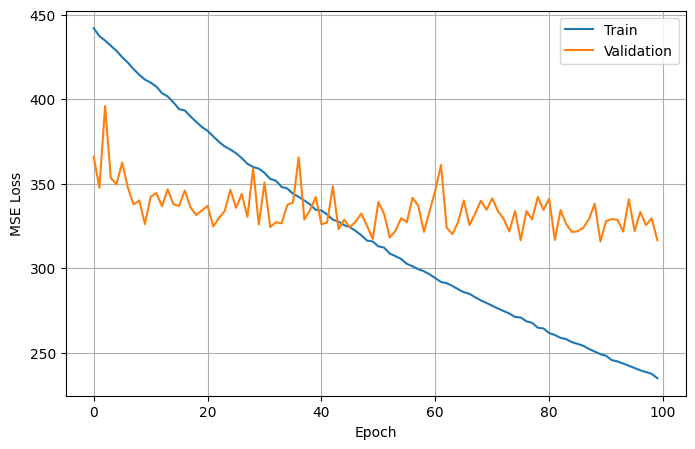

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [21]:
model.eval()

predictions = []
targets = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        targets.append(y_batch.numpy())


predictions = np.concatenate(predictions, axis=0)
targets = np.concatenate(targets, axis=0)


print("Predictions shape:", predictions.shape)
print("Targets shape:", targets.shape)

Predictions shape: (133841, 2)
Targets shape: (133841, 2)


In [22]:
sbp_mae = mean_absolute_error(
    targets[:,0],
    predictions[:,0]
)

dbp_mae = mean_absolute_error(
    targets[:,1],
    predictions[:,1]
)


print(f"SBP MAE: {sbp_mae:.2f} mmHg")
print(f"DBP MAE: {dbp_mae:.2f} mmHg")

SBP MAE: 10.97 mmHg
DBP MAE: 5.93 mmHg


In [23]:
sbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,0],
        predictions[:,0]
    )
)


dbp_rmse = np.sqrt(
    mean_squared_error(
        targets[:,1],
        predictions[:,1]
    )
)


print(f"SBP RMSE: {sbp_rmse:.2f} mmHg")
print(f"DBP RMSE: {dbp_rmse:.2f} mmHg")

SBP RMSE: 15.83 mmHg
DBP RMSE: 8.82 mmHg
